In [5]:
!pip install tensorflow opencv-python mediapipe scikit-learn matplotlib



[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import cv2
import numpy as np
import os
from matplotlib import pyplot as plt
import time
import mediapipe as mp

In [7]:
# this cell is for media pipe holistics and drawing utility
# the holistic is to download the model and leveraging that model
# the drawing utility is just going to make it easier to actually draw the key points on our face
# we will define them as fucntions because we are going to use them pretty often


# the color conversion
#  the opencv capures image in default format that is bgr and to pass it through mediapipe it needs to be in the format of rgb and then we set writeable as false to save some memory and then make predition

In [8]:
mp_holistic = mp.solutions.holistic     #holistic model
mp_drawing = mp.solutions.drawing_utils    #drawing utilities

In [9]:
def mediapipe_detection(image,model):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)   #color conversion bgr to rgb   
    image.flags.writeable = False                    #image is no longer writeable
    results = model.process(image)                   # make prediction
    image.flags.writeable= True                      # image is now writeable
    image = cv2.cvtColor(image,cv2.COLOR_RGB2BGR)    #color conversion rgb to bgr
    return image,results 

In [10]:
import mediapipe as mp

mp_drawing = mp.solutions.drawing_utils
mp_holistic = mp.solutions.holistic
mp_face_mesh = mp.solutions.face_mesh
mp_pose = mp.solutions.pose
mp_hands = mp.solutions.hands




def draw_landmarks(image,results):
    mp_drawing.draw_landmarks(image, results.face_landmarks, mp_face_mesh.FACEMESH_TESSELATION) #draw face cnnections
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_pose.POSE_CONNECTIONS)    #draw pose connections
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_hands.HAND_CONNECTIONS)   #draw left hand connection
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_hands.HAND_CONNECTIONS)     #draw right hand connection
    

In [11]:
# lets update the connection look and style it up a little

def draw_styled_landmarks(image,results):
    mp_drawing.draw_landmarks(image, results.face_landmarks, mp_face_mesh.FACEMESH_TESSELATION,
                              mp_drawing.DrawingSpec(color=(80,110,10), thickness=1 , circle_radius=1),
                              mp_drawing.DrawingSpec(color=(80,256,121), thickness=1 , circle_radius=1)
    )
    
    #draw face cnnections
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_pose.POSE_CONNECTIONS,
                              mp_drawing.DrawingSpec(color=(80,22,10), thickness=2 , circle_radius=1),
                              mp_drawing.DrawingSpec(color=(80,44,121), thickness=2 , circle_radius=1)
                                                            )   
     #draw pose connections
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_hands.HAND_CONNECTIONS,
                              mp_drawing.DrawingSpec(color=(121,22,76), thickness=2 , circle_radius=1),
                              mp_drawing.DrawingSpec(color=(121,44,250), thickness=2 , circle_radius=1)
                                                            )   
    #draw left hand connection
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_hands.HAND_CONNECTIONS,
                              mp_drawing.DrawingSpec(color=(245,117,66), thickness=2 , circle_radius=1),
                              mp_drawing.DrawingSpec(color=(245,66,230), thickness=2 , circle_radius=1)
                                                            )     
    #draw right hand connection
    

In [ ]:
mp_drawing.draw_landmarks

Signature:
mp_drawing.draw_landmarks(
    image: numpy.ndarray,
    landmark_list: mediapipe.framework.formats.landmark_pb2.NormalizedLandmarkList,
    connections: Optional[List[Tuple[int, int]]] = None,
    landmark_drawing_spec: Union[mediapipe.python.solutions.drawing_utils.DrawingSpec, Mapping[int, mediapipe.python.solutions.drawing_utils.DrawingSpec], NoneType] = DrawingSpec(color=(0, 0, 255), thickness=2, circle_radius=2),
    connection_drawing_spec: Union[mediapipe.python.solutions.drawing_utils.DrawingSpec, Mapping[Tuple[int, int], mediapipe.python.solutions.drawing_utils.DrawingSpec]] = DrawingSpec(color=(224, 224, 224), thickness=2, circle_radius=2),
    is_drawing_landmarks: bool = True,
)
Source:   
def draw_landmarks(
    image: np.ndarray,
    landmark_list: landmark_pb2.NormalizedLandmarkList,
    connections: Optional[List[Tuple[int, int]]] = None,
    landmark_drawing_spec: Optional[
        Union[DrawingSpec, Mapping[int, DrawingSpec]]
    ] = DrawingSpec(color=RED_

In [13]:
mp_holistic.FACEMESH_TESSELATION

frozenset({(18, 17),
           (82, 38),
           (8, 9),
           (456, 248),
           (167, 2),
           (303, 271),
           (69, 104),
           (253, 450),
           (41, 42),
           (315, 16),
           (73, 74),
           (339, 373),
           (258, 385),
           (105, 63),
           (219, 48),
           (304, 272),
           (236, 217),
           (231, 22),
           (85, 84),
           (365, 367),
           (237, 218),
           (243, 112),
           (436, 427),
           (409, 410),
           (248, 456),
           (330, 266),
           (136, 135),
           (88, 95),
           (394, 430),
           (107, 108),
           (118, 117),
           (439, 438),
           (442, 443),
           (260, 466),
           (115, 48),
           (342, 276),
           (121, 128),
           (200, 421),
           (113, 124),
           (132, 137),
           (23, 230),
           (343, 357),
           (443, 444),
           (62, 78),
           (26,

In [14]:
cap = cv2.VideoCapture(0)   #this line access our webcam and is stored in avariablke called cap
# set mediapipe model
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:                   #0.5 is the min confidence required to start detecting a landmark, if the models confidence is lower than this it wil ignore the detection and min tracking confidence is also 0.5 so once the model has detected a body part it starts tracking it in the video and this sets the min confidence required to keep tracking if the confidence drops below this threshold tracking stops and the model will try to re detect it

    while cap.isOpened():
        # read the feed
        ret, frame = cap.read()   #reading the current captured frame and its gonna run really fast so all the frames together will make it look like a video
        
        # make detections
        image , results = mediapipe_detection(frame,holistic)
        print(results)
        
        # draw landmarks
        draw_styled_landmarks(image, results)            #we applied this in this loop so that the landmarks will be visible in real time too and not just on last captured frame like we applied
        
        # show to screen
        cv2.imshow('OpenCV  Feed', image) 

        # break gracefully
        if cv2.waitKey(10) & 0xFF == ord('q'):   #waits for 10ms for a key event and then checks if the key pressed is 'q' for exiting
            break 

    cap.release()        #releases the webcam resource
    cv2.destroyAllWindows()    #closes all cv windows

c:\Users\suhan\Envs\myenv\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.soluti

In [15]:
len(results.left_hand_landmarks.landmark)

21

In [16]:
frame                    #the last frame that was captured by opencv

array([[[149, 144, 139],
        [153, 144, 137],
        [158, 145, 136],
        ...,
        [138, 134, 117],
        [139, 135, 118],
        [139, 135, 118]],

       [[148, 144, 138],
        [150, 143, 136],
        [154, 143, 134],
        ...,
        [139, 135, 118],
        [139, 135, 118],
        [139, 135, 118]],

       [[152, 149, 142],
        [149, 145, 137],
        [148, 142, 134],
        ...,
        [139, 135, 117],
        [139, 135, 117],
        [139, 135, 117]],

       ...,

       [[186, 170, 170],
        [161, 149, 150],
        [153, 144, 147],
        ...,
        [193, 180, 162],
        [192, 179, 160],
        [191, 178, 159]],

       [[164, 142, 141],
        [153, 137, 139],
        [147, 138, 142],
        ...,
        [192, 179, 160],
        [191, 178, 158],
        [188, 176, 156]],

       [[166, 140, 139],
        [152, 135, 136],
        [148, 139, 144],
        ...,
        [188, 176, 156],
        [189, 177, 157],
        [188, 176, 155]]

In [17]:
results

mediapipe.python.solution_base.SolutionOutputs

In [18]:
draw_landmarks(frame, results)       #the landmarks points you see is because of this this will help show landmarks points of face hand pose and all this is to actiovate it

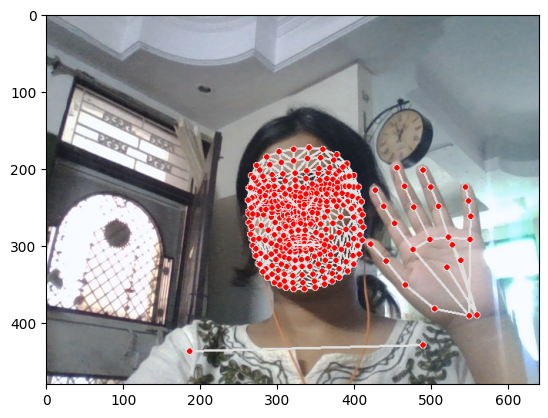

In [19]:
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))  #last frme if you wanna show than you can use matplotlib and then we use color conversion to intensify the colors properly

In [20]:
len(results.pose_landmarks.landmark)

33

In [21]:
pose = []
for res in results.pose_landmarks.landmark:
    test = np.array([res.x, res.y , res.z , res.visibility])
    pose.append(test)

In [22]:
pose = (np.array([[res.x,res.y,res.z, res.visibility] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(132))     #flatten will convert all into one big array because we will need this type of formatting to pass it to our lstm model
lh = (np.array([[res.x , res.y , res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3))               #21*3 we are doing because 21 is the size of lh landmarks and 3 are the coordinates that is x y and z so for each 3 are there we can check by part.shape like pose.shape and then accordingly design the rest
rh = (np.array([[res.x , res.y , res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3))            #this will throw error if right hand or specified body part isnt in the frame so we will include if statement so it doesnt throw error and will give some result
face = (np.array([[res.x , res.y , res.z] for res in results.face_landmarks.landmark]).flatten() if results.face_landmarks else np.zeros(21*3)) 

In [23]:
# checking size of face landmark to create blank array

len(results.face_landmarks.landmark)*3

1404

In [24]:
lh.shape

(63,)

In [25]:
rh

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [ ]:
def extract_keypoints(result):
    pose = (np.array([[res.x,res.y,res.z, res.visibility] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(33*4))     #flatten will convert all into one big array because we will need this type of formatting to pass it to our lstm model
    lh = (np.array([[res.x , res.y , res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3))               #21*3 we are doing because 21 is the size of lh landmarks and 3 are the coordinates that is x y and z so for each 3 are there we can check by part.shape like pose.shape and then accordingly design the rest
    rh = (np.array([[res.x , res.y , res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3))            #this will throw error if right hand or specified body part isnt in the frame so we will include if statement so it doesnt throw error and will give some result
    face = (np.array([[res.x , res.y , res.z] for res in results.face_landmarks.landmark]).flatten() if results.face_landmarks else np.zeros(468*3)) 
    return np.concatenate([pose,lh,rh,face])

In [27]:
result_test = extract_keypoints(results)

In [28]:
result_test

array([ 0.52268243,  0.54050535, -0.78031933, ...,  0.59158385,
        0.47051516,  0.0221279 ])

In [29]:
np.save('0' , result_test)

In [30]:
np.load('0.npy')

array([ 0.52268243,  0.54050535, -0.78031933, ...,  0.59158385,
        0.47051516,  0.0221279 ])

In [31]:
# Path for exported data, numpy arrays
DATA_PATH = os.path.join('MP_Data')

# Actions that we try to detect
actions = np.array(['hello' , 'thanks' , 'iloveyou'])

# thirty videos worth of data that means for every action 30 videos are going to be there to identify whats the sign for
no_sequence = 30 

# videos are going to be 30 frames in length
sequence_length = 30     

In [32]:
# hello
# so for hello also from 0 to 3 videos will be there each video will have 30 frames
# 0
# 1
# 29

# so basically 3 actions 30 videos per action and 30 frames per video

In [33]:
for action in actions:            #for every action
    for sequence in range(no_sequence):    #for every video
        try:
            os.makedirs(os.path.join(DATA_PATH, action ,str(sequence)))   #check exception and create subdirectories for action and all the sequence of frame
        except:
            pass    

5. Collect Keypoint Values for Training and Testing

In [34]:
cap = cv2.VideoCapture(0)   #this line access our webcam and is stored in avariablke called cap   #reading the current captured frame and its gonna run really fast so all the frames together will make it look like a video
        # new loop
        # loop through actions
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
        for action in actions:
            # loop through sequences aka videos
            for sequence in range(sequence_length):
                # loop through video length aka sequence length
                for frame_num in range(sequence_length):
                     
                 
                    #  read feed
                    ret , frame = cap.read()
                    # make detections
                    image , results = mediapipe_detection(frame,holistic)
                    print(results)
        
                    # draw landmarks
                    draw_styled_landmarks(image, results)            #we applied this in this loop so that the landmarks will be visible in real time too and not just on last captured frame like we applied

                    # apply collection logic
                    if frame_num == 0 :
                        cv2.putText(image, 'STARTING_COLLECTION', (120,200),
                                   cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0),4, cv2.LINE_AA )
                        
                        cv2.putText(image,'Collecting frames for {} video number {}'.format(action, sequence), (15,12),
                                    cv2.FONT_HERSHEY_SIMPLEX, 0.5,(0,0,255),4,cv2.LINE_AA)
                        cv2.waitKey(2000)

                    else:
                        cv2.putText(image, 'Collecting frames for {} video number {}'.format(action,sequence),(15,12),
                                     cv2.FONT_HERSHEY_SIMPLEX,0.5, (0,0,255), 1 , cv2.LINE_AA) 

                    # show to screen
                        cv2.imshow('OpenCV  Feed', image) 

                    # new export keypoints
                    keypoints = extract_keypoints(results)
                    npy_path = os.path.join(DATA_PATH, action , str(sequence), str(frame_num))
                    np.save(npy_path , keypoints)       
 

                    # break gracefully
                    if cv2.waitKey(10) & 0xFF == ord('q'):   #waits for 10ms for a key event and then checks if the key pressed is 'q' for exiting
                        break 
 
        cap.release()        #releases the webcam resource
        cv2.destroyAllWindows()    #closes all cv windows

<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.soluti

In [35]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

In [36]:
label_map = {label:num for num , label in enumerate(actions)}

In [37]:
label_map

{np.str_('hello'): 0, np.str_('thanks'): 1, np.str_('iloveyou'): 2}

In [38]:
sequences , labels = [] , []
for action in actions:
    for sequence in range(no_sequence):
        window =[]
        for frame_num in range(sequence_length):
            res = np.load(os.path.join(DATA_PATH, action , str(sequence), "{}.npy".format(frame_num)))
            window.append(res)
        sequences.append(window)
        labels.append(label_map[action])    

In [40]:
np.array(sequences).shape

(90, 30, 1662)

In [41]:
np.array(labels).shape

(90,)

In [43]:
x = np.array(sequences)

In [45]:
y = to_categorical(labels).astype(int)

In [46]:
y

array([[1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0,

In [47]:
x_train , x_test , y_train , y_test = train_test_split(x,y, test_size = 0.05)

In [48]:
x_train.shape

(85, 30, 1662)

In [49]:
x_test.shape

(5, 30, 1662)

Build and Train LSTM Neural Network

In [50]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import TensorBoard

In [51]:
log_dir = os.path.join('Logs')
tb_callback = TensorBoard(log_dir=log_dir)

In [52]:
model = Sequential()
model.add(LSTM(64, return_sequences=True , activation='relu', input_shape=(30,1662)))
model.add(LSTM(128, return_sequences=True, activation='relu'))
model.add(LSTM(64, return_sequences=False, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(actions.shape[0], activation='softmax'))

c:\Users\suhan\Envs\myenv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [54]:
model.compile(optimizer='Adam', loss='categorical_crossentropy',metrics=['categorical_accuracy'])

In [55]:
model.fit(x_train , y_train, epochs=2000, callbacks=[tb_callback])

Epoch 1/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 158ms/step - categorical_accuracy: 0.3412 - loss: 1.9227
Epoch 2/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - categorical_accuracy: 0.4353 - loss: 1.4196
Epoch 3/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - categorical_accuracy: 0.3294 - loss: 1.8692
Epoch 4/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - categorical_accuracy: 0.4471 - loss: 1.5767
Epoch 5/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - categorical_accuracy: 0.4353 - loss: 1.0470
Epoch 6/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - categorical_accuracy: 0.3647 - loss: 1.0811
Epoch 7/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - categorical_accuracy: 0.5529 - loss: 0.9700
Epoch 8/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - categorical_accuracy: 0.5412 - loss: 0.8041
Epoch 9/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - categorical_accuracy: 0.6235 - loss: 0.7127
Epoch 10/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - categorical_accuracy: 0.8235 - loss: 0.5237
Epoch 11/2000
3/3 

KeyboardInterrupt: 

In [56]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │       442,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,790,027 (6.83 MB)

 Trainable params: 596,675 (2.28 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,193,352 (4.55 MB)

Make Predictions

In [58]:
res= model.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step


In [63]:
actions[np.argmax(res[0])]

np.str_('hello')

In [65]:
actions[np.argmax(y_test[1])]

np.str_('iloveyou')

Save Weights


In [66]:
model.save('action.h5')

Evaluation using Confusion Matrix and ACCuracy

In [67]:
from sklearn.metrics import multilabel_confusion_matrix, accuracy_score

In [68]:
yhat = model.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step


In [69]:
ytrue = np.argmax(y_test, axis=1).tolist()
yhat = np.argmax(yhat, axis=1).tolist()

In [70]:
yhat

[0, 2, 2, 1, 2]

In [71]:
ytrue

[1, 2, 2, 1, 2]

In [72]:
multilabel_confusion_matrix(ytrue , yhat)

array([[[4, 1],
        [0, 0]],

       [[3, 0],
        [1, 1]],

       [[2, 0],
        [0, 3]]])

In [73]:
multilabel_confusion_matrix??

Signature:
multilabel_confusion_matrix(
    y_true,
    y_pred,
    *,
    sample_weight=None,
    labels=None,
    samplewise=False,
)
Source:   
@validate_params(
    {
        "y_true": ["array-like", "sparse matrix"],
        "y_pred": ["array-like", "sparse matrix"],
        "sample_weight": ["array-like", None],
        "labels": ["array-like", None],
        "samplewise": ["boolean"],
    },
    prefer_skip_nested_validation=True,
)
def multilabel_confusion_matrix(
    y_true, y_pred, *, sample_weight=None, labels=None, samplewise=False
):
    """Compute a confusion matrix for each class or sample.

    .. versionadded:: 0.21

    Compute class-wise (default) or sample-wise (samplewise=True) multilabel
    confusion matrix to evaluate the accuracy of a classification, and output
    confusion matrices for each class or sample.

    In multilabel confusion matrix :math:`MCM`, the count of true negatives
    is :math:`MCM_{:,0,0}`, false negatives is :math:`MCM_{:,1,0}`,
    true 

In [74]:
accuracy_score(ytrue , yhat)

0.8

Test in Real Time

In [81]:
colors= [(245,117,16) , (117,245,16), (16,117,245)]
def prob_viz(res, actions , input_frame, colors):
    output_frame = input_frame.copy()
    for num , prob in enumerate(res):
        cv2.rectangle(output_frame, (0,60+num*40), (int(prob*100), 90+num*40), colors[num], -1)
        cv2.putText(output_frame, actions[num], (0, 85+num*40),cv2.FONT_HERSHEY_SIMPLEX,1 , (255,255,255), 2 , cv2.LINE_AA)

    return output_frame    

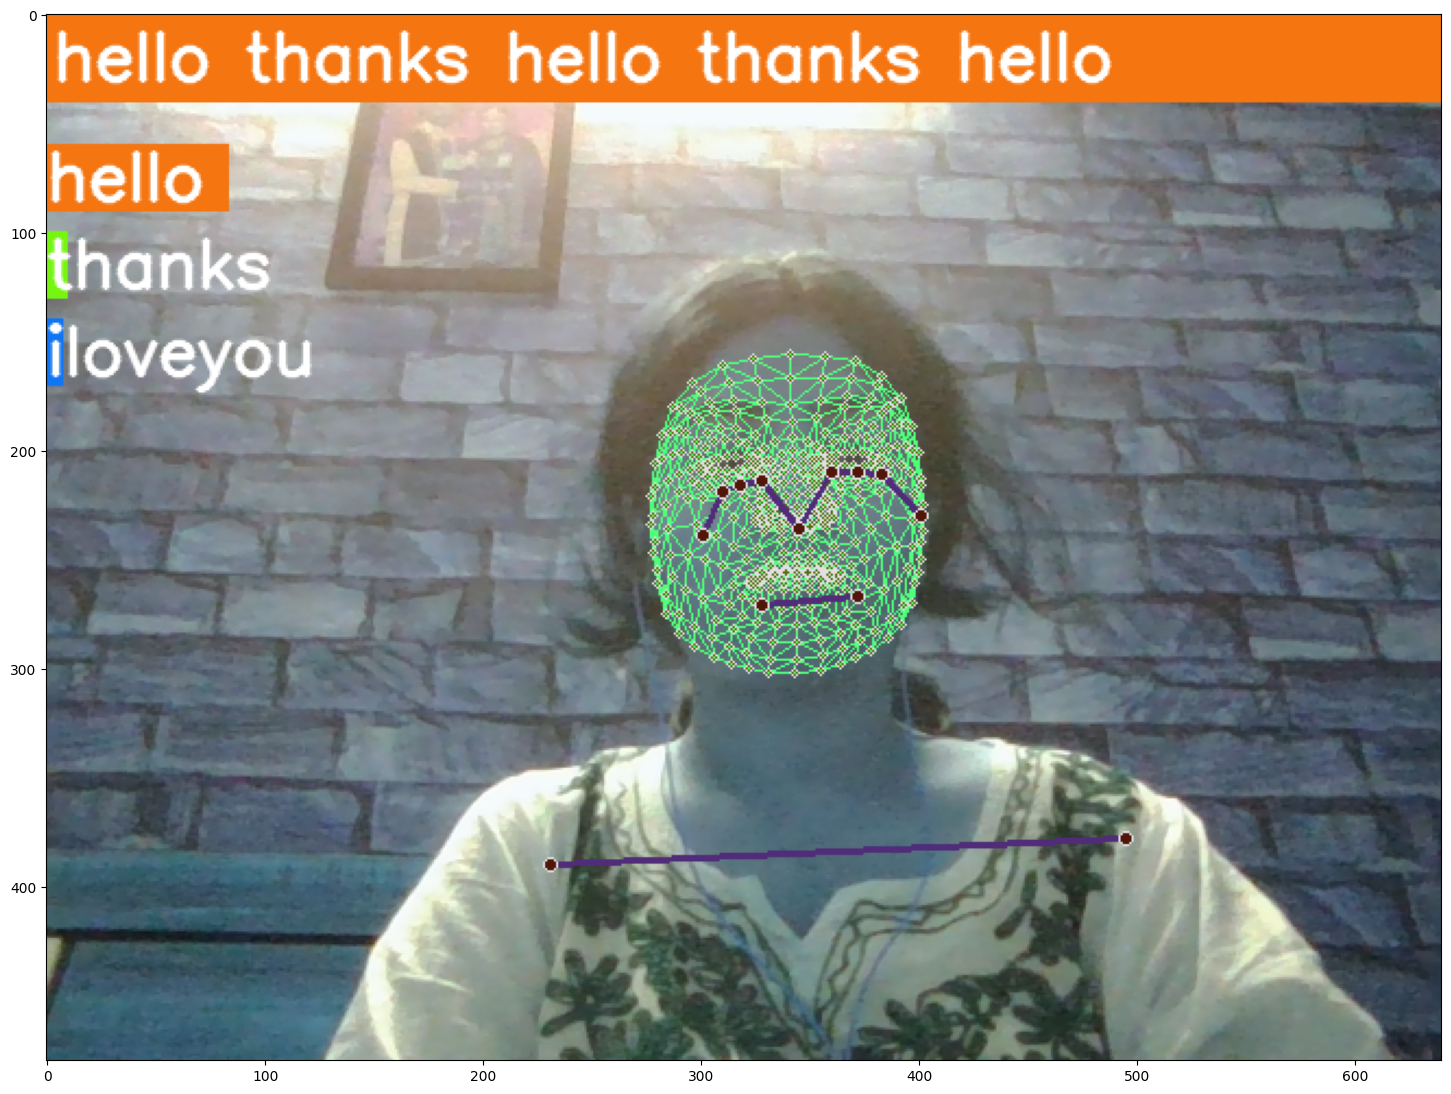

In [83]:
plt.figure(figsize=(18,18))
plt.imshow(prob_viz(res , actions , image , colors))

In [84]:
# 1. New detection variables
sequence = []
sentence = []
threshold = 0.7




cap = cv2.VideoCapture(0)  

with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:                   #0.5 is the min confidence required to start detecting a landmark, if the models confidence is lower than this it wil ignore the detection and min tracking confidence is also 0.5 so once the model has detected a body part it starts tracking it in the video and this sets the min confidence required to keep tracking if the confidence drops below this threshold tracking stops and the model will try to re detect it

    while cap.isOpened():
        # read the feed
        ret, frame = cap.read()   #reading the current captured frame and its gonna run really fast so all the frames together will make it look like a video
        
        # make detections
        image , results = mediapipe_detection(frame,holistic)
        print(results)
        
        # draw landmarks
        draw_styled_landmarks(image, results)            #we applied this in this loop so that the landmarks will be visible in real time too and not just on last captured frame like we applied
        

        # 2. Prediction Logic
        keypoints = extract_keypoints(results)
        sequence.insert(0,keypoints)
        sequence = sequence[:30]

        if len(sequence) == 30:
            res = model.predict(np.expand_dims(sequence, axis=0))[0]
            print(actions[np.argmax(res)])


        # 3. Viz Logic
        if res[np.argmax(res)] > threshold:
            if len(sentence) > 0:
                if actions[np.argmax(res)] != sentence[-1]:
                    sentence.append(actions[np.argmax(res)])
            else:
                 sentence.append(actions[np.argmax(res)])

        if len(sentence) > 5:
            sentence = sentence[-5:]

        # viz probablities
        image = prob_viz(res , actions, image , colors) 

        cv2.rectangle(image, (0,0), (640,40), (245,117,16), -1)
        cv2.putText(image, ' '.join(sentence),(3,30),
                    cv2.FONT_HERSHEY_SIMPLEX,1, (255,255,255), 2 , cv2.LINE_AA)                
                          

        # show to screen
        cv2.imshow('OpenCV  Feed', image) 

        # break gracefully
        if cv2.waitKey(10) & 0xFF == ord('q'):   #waits for 10ms for a key event and then checks if the key pressed is 'q' for exiting
            break 

    cap.release()        #releases the webcam resource
    cv2.destroyAllWindows()    #closes all cv windows

c:\Users\suhan\Envs\myenv\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.soluti

In [ ]:
np.expand_dims(x_test[0], axis=0).shape

(1, 30, 1662)

In [77]:
model.predict(np.expand_dims(x_test[0],axis=0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


array([[0.8399541 , 0.09003941, 0.07000656]], dtype=float32)